# Spike clusters

**author**: laquitainesteeve@gmail.com

**purpose**: Cluster action potential (APs) shapes with WaveMap for Marques-Smith KS3-sorted APs.

**Tested on**:
* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

**Execution time**: 2 mins

**Special hardware**: 
    * on CPU, does not require GPU.
    * Required resources: 184 GB RAM

**Method**: 

- recording duration: ??
- selected sorted single-units only
- traces are whitened to increasing denoising (as in Kilosort)
- PEAK_SIGN is 'neg' rather than 'both' when generating templates to find the nearest site.
- aligned each sorted unit waveforms based on their negative peak (trough) searched in a short window of 2.5 ms surrounding the trough, to prevent waveform collisions.
- wavemap louvain clustering set to resolution 1.5 (as in wavemap paper) instead of default 1.
- we removed clusters with less than 5 units


## Setup

Prerequisites:

1. Setup "_envs/demo.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name demo --display-name "demo"_
3. Download with notebooks/1_results/0_download_recordings.ipynb and 0_download_sortings.ipynb




In [16]:
%%time
%load_ext autoreload
%autoreload 2

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import packages
import os
import shutil
import numpy as np
from dandi.dandiapi import DandiAPIClient
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from spikeinterface import extract_waveforms
import spikeinterface.core.template_tools as ttools
from spikeinterface.core.sparsity import compute_sparsity
from matplotlib import pyplot as plt;
import multiprocessing
import pandas as pd
import matplotlib
import sys
from scipy.stats import kruskal
import scikit_posthocs as sp
import sklearn
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp # set context "fork" for macOS or "spawn"
import random 
from umap import umap_ as umap
import networkx as nx
import community as community_louvain
from collections import Counter
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

print("spikeinterface version:", si.__version__)

# project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias/"
os.chdir(proj_path)

# import spikebias package
from src.nodes.utils import get_config, demean
from src.nodes.validation import snr
from src.nodes.validation import amplitude, power_demo, power

# setup dataset paths
# npx_spont
RECORDING_NS_PATH = 'dataset/00_raw/recording_npx_spont'
SORTING_NS_KS3_PATH = 'dataset/01_intermediate/sorting/npx_spont/SortingKS3'

# setup recording preprocessing parameters
FREQ_MIN = 300
FREQ_MAX = 3000            # TO TEST (the higher and the more resolution to find fast spiking waveforms, but the more noise)
REFERENCE = "global"       # common reference preprocessing
OPERATOR = "median"        # common reference preprocessing

# setup waveforms parameters
PEAK_SIGN = "neg"
METHOD = 'radius'          # compute sparse waveforms within radius of the nearest electrode
RADIUS_UM = 40             # compute sparse waveforms radius
EXT_PARAMS = {'waveforms': {'ms_before': 3, 'ms_after': 3},                                   # TEST shorter waveforms (less variability) 
              'templates': {'operators': ['average', 'std'], 'ms_before': 3, 'ms_after': 3},  # TEST shorter templates (less variability) 
              'random_spikes': {'max_spikes_per_unit': 1e6, 'seed': 0}}                      # TEST more waveforms

WAVE_PATH = os.path.join(proj_path + "temp/waveforms/npx_spont/SortingKS3")
N_JOBS = 20                 # (default = 20) number of parallel processes for waveform extraction (20/32)
CHUNKS = 50000              # (default = 800000) use smaller chunks to use less RAM
JOB_KWARGS = dict(n_jobs=N_JOBS, chunk_size=800000, progress_bar=True)   # 20/32 cores

# setup template parameters
# these make the average waveform (template) more robust to outlier waveforms
# and more representative to the majority of observed waveforms
ABS_DEV = 0.4        # (default=0.4) as in lee et al 2021's wavemap paper - heuristic curation of single-units
N_STD_OF_MEAN = 2    # (default=2) as in lee et al 2021's wavemap paper - heuristic curation of single-units

# wavemap parameters
RAND_STATE = 4
N_NEIGHBORS = 15
N_SITES = 4

clusters_color_map = {
    0: (0.902, 0.698, 0.298),
    1: (0.800, 0.698, 0.200),
    2: (0.800, 0.749, 0.200),
    3: (1.000, 0.000, 0.000),
    4: (0.329, 0.290, 0.580),
    5: (0.439, 0.651, 0.788),
    6: (0.541, 0.749, 0.890),
    7: (0.639, 0.851, 0.988),
    8: (0.996, 0.922, 0.886),
    9: (0.988, 0.773, 0.753),
}

AP_colors = np.array( 
    [
        [0.9, 0.7, 0.3],  # yellow/gold
        [0.8, 0.70, 0.2],  # lighter yellow/green
        [0.8, 0.75, 0.2],  # lightest yellow/green
        [1, 0, 0],  # red
        [0.33, 0.29, 0.58],  # purple blue
        [0.44, 0.65, 0.79],  # light blue
        [0.54, 0.75, 0.89],  # lighter blue
        [0.64, 0.85, 0.99],  # lightest blue
        [254 / 255, 235 / 255, 226 / 255],  # purple variation
        [252 / 255, 197 / 255, 192 / 255],  # purple variation
        [250 / 255, 159 / 255, 181 / 255],  # purple variation
    ]
)

# plot parameters
FIG_SIZE = (1.5, 1.5)
cl = dict()
cl["COLOR_NS"] = [0.9, 0.14, 0.15]
cl["COLOR_NE"] = [1, 0.49, 0] # orange
cl["COLOR_MEDIAN"] = (1, 0.76, 0)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically 0.5 - 1 pt
plt.rcParams["axes.linewidth"] = 0.5 # typically 0.5 - 1 pt
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1
N_MAJOR_TICKS = 4
N_MINOR_TICKS = 12
savefig_cfg = {"transparent":True, "dpi":400}
legend_cfg = {"frameon": False, "handletextpad": 0.1}
tight_layout_cfg = {"pad": 0.5}
LG_FRAMEON = False              # no legend frame

FIG_SIZE = (1, 1)
pm = {
    "linestyle": "None",
    "marker": "o",
    "markersize": 1.5,
    "rasterized": True,
    "markeredgecolor": "w",
    "markeredgewidth": 0.06,
}
pm_fit1 = {
    "linestyle": "-",
    "linewidth": 0.5,
    "color": "k",
}
pm_fit2 = {
    "linestyle": "-",
    "linewidth": 0.5,
    "color": "k",
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
spikeinterface version: 0.101.2
CPU times: user 637 μs, sys: 0 ns, total: 637 μs
Wall time: 343 μs


## clear RAM

In [2]:
# clear RAM
import getpass; password = getpass.getpass("Enter your sudo password: ")
!sync; echo {password} | sudo -S sh -c 'echo 1 > /proc/sys/vm/drop_caches'

[sudo] password for steeve: 

## Functions

In [3]:
def get_nearest_site(templates_by_site):
    trough_amplitude = np.nanmin(templates_by_site, axis=1)

    # catch exception
    if np.isnan(trough_amplitude).all():
        index = None
    else:
        index = np.nanargmin(np.nanmin(templates_by_site, axis=1))
    return index


def get_waveforms_for(cell_id, waveform_extension):
    return waveform_extension.get_waveforms_one_unit(unit_id=cell_id)


def align_by_neg_peak_and_crop(
    waves, sampling_frequency, window_to_search_peak_sec=2.5, window=100, peak_pos=50
):
    """
    W: array of shape (n_waveforms, n_samples) e.g. (N, 480)
    window: number of samples in the output window (e.g. 100)
    peak_pos: index in [0, window-1] where the negative peak will be placed (e.g. 50)
    fill_value: value used when the 100-sample window would run beyond the edges
    Returns: array of shape (n_waveforms, window)
    """

    # find peak index in shortened waveform
    # shorten waveform to find peak without spike collision
    short_waves, wind_start, wind_end = shorten_waveform(
        waves,
        window_to_search_peak_sec=window_to_search_peak_sec,
        sampling_freq=sampling_frequency,
    )

    num_waves, _ = short_waves.shape
    left = peak_pos
    right = window - left  # number of samples to include to the right of the peak
    aligned = np.full(
        (num_waves, window), np.nan, dtype=short_waves.dtype
    )  # placeholder of nans

    # index of negative peak for each waveform
    trough_idx = np.argmin(short_waves, axis=1)

    # locate peak index in longer waveforms
    trough_idx = trough_idx + wind_start

    # number of timepoints in longer waves
    n_timepoints = waves.shape[1]

    for w_ix in range(num_waves):

        # desired window in original signal: [p-left, p+right)
        src_start = max(0, trough_idx[w_ix] - left)
        src_end = min(n_timepoints, trough_idx[w_ix] + right)

        # where to place it in the output (shift if we clipped at edges)
        dst_start = max(
            0, left - trough_idx[w_ix]
        )  # how many samples we clipped on the left
        dst_end = dst_start + (src_end - src_start)

        # align
        aligned[w_ix, dst_start:dst_end] = waves[w_ix, src_start:src_end]
    return aligned


def shorten_waveform(
    waveforms: np.array, window_to_search_peak_sec=2.5, sampling_freq=40000
):

    # calculate shorter window
    sample_sec = (1 / sampling_freq) * 1000
    shorter_window = int(window_to_search_peak_sec / sample_sec)

    # get shorter window
    mid_point = int(waveforms.shape[1] / 2)
    wind_start = int(mid_point - shorter_window / 2)
    wind_end = int(mid_point + shorter_window / 2)
    shorter_window_sample = np.arange(wind_start, wind_end, 1).astype(int)
    return waveforms[:, shorter_window_sample], wind_start, wind_end


def get_single_unit_ids(Sorting):
    single_unit_ix = np.where(Sorting.get_property("KSLabel") == "good")[0]
    return Sorting.unit_ids[single_unit_ix]


def filter_best_set_of_waves_for_the_mean(waves, n_std_of_mean=2, abs_dev=0.4):
    """see wavemap paper
    DOI: https://doi.org/10.7554/eLife.67490

    Args:
        waves (np.array): (n_waveforms, n_timepoints)

    Returns:
        selected_waves
        selected_indices
    """

    # mean and per-time-point std of the waveforms
    mean_wave = np.nanmean(waves, axis=0)
    std_wave = np.nanstd(
        waves, axis=0
    )  # ddof=0 (population). Use ddof=1 if you prefer sample std.

    # Avoid divide-by-zero where a time point has zero variance
    std_safe = np.where(std_wave == 0, 1.0, std_wave)

    # Condition A: every time point is within ±2 std of the mean (pointwise)
    z = (waves - mean_wave) / std_safe
    within_2std = np.all(np.abs(z) <= n_std_of_mean, axis=1)

    # Condition B: average absolute deviation from the mean across time < 0.4
    avg_abs_dev = np.nanmean(np.abs(waves - mean_wave), axis=1)
    low_avg_dev = avg_abs_dev < abs_dev

    # Final selection
    mask = within_2std & low_avg_dev
    selected_indices = np.flatnonzero(mask)
    selected_waves = waves[mask]
    return selected_waves, selected_indices


def calculate_template(
    cell_id,
    analyzer,
    wave_ext,
    sfreq,
    peak_sign="neg",
    window_to_search_peak_sec=2.5,
    window=100,
    peak_pos=50,
    n_std_of_mean=2,
    abs_dev=0.4,
):
    """_summary_

    Args:
        cell_id (int): _description_
        analyzer (_type_): _description_
        wave_ext (_type_): _description_
        sfreq (int): recording sampling frequency
        peak_sign (str, optional): _description_. Defaults to 'neg'
        window (int): number of timepoints of produced template
        peak_pos: index of the trough in the produced template
        n_std_of_mean (int): for filtering best waveforms - see wavemap paper
        abs_dev (float): for filtering best waveforms - see wavemap paper

    Returns:
        dict:
        - 'templates': templates for the cell's nearby sites of shape (n_sites, n_timepoints)
    """
    # get waveforms and the index of the nearest site
    waves = get_waveforms_for(cell_id, wave_ext)

    # get number of nearby sites
    _, _, n_sites = waves.shape

    templates = []

    for site_ix in range(n_sites):

        # align waveforms
        aligned = align_by_neg_peak_and_crop(
            waves[:, :, site_ix],
            sfreq,
            window_to_search_peak_sec=window_to_search_peak_sec,
            window=window,
            peak_pos=peak_pos,
        )

        # filter the best waveforms to calculate a reliable template
        # waveforms should be short (else high noise away from waveform prevents waveform selection)
        filtered, _ = filter_best_set_of_waves_for_the_mean(
            aligned, n_std_of_mean=n_std_of_mean, abs_dev=abs_dev
        )

        # calculate template
        templates.append(np.nanmean(filtered, axis=0))

    templates = np.array(templates)

    # get nearby site ids
    site_ids = analyzer.sparsity.unit_id_to_channel_ids[cell_id]

    # get nearest sites (found within sparse nearby sites)
    nearest_site_ix = get_nearest_site(templates)
    nearest_site_id = site_ids[nearest_site_ix]

    return {
        "templates": templates,
        "nearest_site_index": nearest_site_ix,
        "nearest_site_id": nearest_site_id,
        "nearby_site_ids": site_ids,
    }


def apply_wavemap(
    downsampled_nearest_site_templates,
    rand_state,
    n_neighbors=15,
    n_components=3,
    resolution=1.5,
    verbose=False,
):

    # setup reproducibility
    np.random.seed(rand_state)
    os.environ["PYTHONHASHSEED"] = str(rand_state)
    random.seed(rand_state)

    # normalize waveforms between -1 and 1.
    scaler = MinMaxScaler(feature_range=(-1, 1))
    normalized = scaler.fit_transform(downsampled_nearest_site_templates.T).T

    # reduce dimensionality with UMAP (defaults to 2D)
    reducer = umap.UMAP(
        n_neighbors=n_neighbors, n_components=n_components, random_state=rand_state
    )
    mapper = reducer.fit(normalized)

    # clustering with Louvain
    G = nx.from_scipy_sparse_array(mapper.graph_)
    clustering = community_louvain.best_partition(
        G, resolution=resolution, random_state=rand_state
    )
    clustering_solution = list(clustering.values())

    # calculate this partition's quality (modularity index)
    modularity = community_louvain.modularity(clustering, G)

    # create 2D embedding
    embedding = reducer.fit_transform(normalized)

    # label dimensions
    nb_dims = embedding.shape[1]
    dimensions = tuple(np.arange(0, nb_dims, 1))

    # get cluster profiles
    umap_df = pd.DataFrame(embedding, columns=dimensions)
    umap_df["waveform"] = list(normalized)
    umap_df["cluster_id"] = clustering_solution
    profiles = np.unique(umap_df["cluster_id"])
    if verbose:
        print("nb of shape profiles:", len(profiles))
    return normalized, umap_df, profiles, modularity


def get_multi_site_templates(templates: np.array, n_sites=6):

    # get indices of n_sites (6) with the largest
    # trough, in ascending order
    mins = np.min(templates, axis=1)
    neg_idx = np.flatnonzero(mins < 0)
    order = np.argsort(mins[neg_idx])
    sorted_indices = neg_idx[order]
    # return templates for these sites,
    # in ascending order
    return templates[sorted_indices[:n_sites], :]


def plot_embedding(ax, umap_df, profiles, colors):

    # plot
    for ix, profile_i in enumerate(profiles):
        ax.scatter(
            umap_df[0][umap_df["cluster_id"] == profile_i].tolist(),
            umap_df[1][umap_df["cluster_id"] == profile_i].tolist(),
            marker="o",
            color=colors[ix],
            label=profile_i,
            s=20,
            edgecolors="w",
        )

    # aesthetics
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylabel("Feature 1 (a.u)")
    ax.set_xlabel("Feature 2 (a.u)")

    # legend
    ax.legend(
        fontsize=7,
        bbox_to_anchor=(1, 1.1),
        labelspacing=0.1,
        **{"frameon": False, "handletextpad": 0.1},
    )
    return ax


def plot_embedding_3D(ax, umap_df, profiles, colors):

    # plot
    for ix, profile_i in enumerate(profiles):
        ax.scatter(
            xs=umap_df[0][umap_df["cluster_id"] == profile_i].tolist(),
            ys=umap_df[1][umap_df["cluster_id"] == profile_i].tolist(),
            zs=umap_df[2][umap_df["cluster_id"] == profile_i].tolist(),
            marker="o",
            color=colors[ix],
            label=profile_i,
            s=10,
        )

    # aesthetics
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Feature 1 (a.u)")
    ax.set_ylabel("Feature 2 (a.u)")
    ax.set_zlabel("Feature 3 (a.u)")

    # legend
    ax.legend(
        fontsize=20,
        bbox_to_anchor=(1, 1.1),
        labelspacing=0.1,
        **{"frameon": False, "handletextpad": 0.1},
    )
    return ax


def plot_profiles(
    ax, normWFs, umap_df, profiles, colors, is_title=True, is_ylabel=True
):

    # plot templates per shape profile
    for ix in range(len(profiles)):
        ax[ix].plot(
            normWFs[umap_df["cluster_id"] == ix].T,
            color=colors[ix],
            alpha=0.5,
            linewidth=1,
        )
        if is_title:
            ax[ix].set_title(str(ix), fontsize=7)
        if is_ylabel:
            ax[ix].set_ylabel(str(ix), fontsize=7)
    return ax


def get_multi_site_templates_for_wavemap(
    templates_dict, n_sites=6, downsampling=2, scaling=True
):

    # get multi-site templates
    multi_sites_templates = []
    unit_ids = []
    for ix, unit_id in tqdm(enumerate(templates_dict)):

        templates = templates_dict[unit_id]["templates"]

        # catch exception
        if (templates.shape[0] >= n_sites) and (not np.isnan(templates).any()):
            tmp = get_multi_site_templates(templates, n_sites=n_sites)
            multi_sites_templates.append(tmp)
            unit_ids.append(unit_id)

    multi_sites_templates = np.array(
        multi_sites_templates
    )  # (n_units, n_sites (=6), n_timepoints)
    multi_sites_templates = multi_sites_templates[
        :, :, ::downsampling
    ]  # downsample waveforms to 50 timepoints

    # scale each nearby channel between -1 and 1
    if scaling:

        # create scaler
        scaler = MinMaxScaler(feature_range=(-1, 1))

        # normalize each site's waveform between -1 and 1
        # make an array (n_units, n_sites (=6), n_timepoints)
        normalized = []
        for ix in range(multi_sites_templates.shape[0]):
            normalized.append(scaler.fit_transform(multi_sites_templates[ix, :, :].T).T)
        multi_sites_templates = np.array(normalized)

    # concatenate waveforms across sites per unit
    return multi_sites_templates.reshape(multi_sites_templates.shape[0], -1), unit_ids


def compute_template_data(
    single_units,
    analyzer,
    wave_ext,
    sfreq,
    peak_sign,
    window_to_search_peak_sec,
    window_samples,
    peak_pos_sample,
    n_std_of_mean,
    abs_dev,
):
    # calculate the templates on (30) nearby sites for each unit
    templates_dict_e = dict()
    for _, unit_id in tqdm(enumerate(single_units)):
        templates_dict_e[unit_id] = calculate_template(
            unit_id,
            analyzer,
            wave_ext,
            sfreq,
            peak_sign=peak_sign,
            window_to_search_peak_sec=window_to_search_peak_sec,
            window=window_samples,
            peak_pos=peak_pos_sample,
            n_std_of_mean=n_std_of_mean,
            abs_dev=abs_dev,
        )
    return templates_dict_e


def find_best_resolution(
    templates,
    rand_state=0,
    n_neighbors=15,
    n_components=2,
    resolution_range=np.arange(0.1, 5, 0.1),
    verbose=False,
):
    """
    Find the best resolution that maximizes modularity for given templates.

    Args:
        templates (np.ndarray): Input templates for clustering.
        rand_state (int): Random state for reproducibility.
        n_neighbors (int): Number of neighbors for UMAP.
        n_components (int): Number of components for UMAP.
        resolution_range (np.ndarray): Range of resolution values to test.

    Returns:
        float: Best resolution value.
        list: List of modularity values for each resolution.
    """
    modularities = []
    for resolution_i in resolution_range:
        _, _, _, modularity = apply_wavemap(
            templates,
            rand_state,
            n_neighbors=n_neighbors,
            n_components=n_components,
            resolution=resolution_i,
            verbose=verbose,
        )
        modularities.append(modularity)
    best_resolution = resolution_range[np.argmax(modularities)]
    return best_resolution, modularities

## Load datasets

In [4]:
%%time 

# load npx_spont recordingg and sorting extractors
RecordingNS = si.load_extractor(RECORDING_NS_PATH)
print('Recording:', RecordingNS)

SortingNS = si.load_extractor(SORTING_NS_KS3_PATH)
print('Sorting:', SortingNS)

single_units_ns = get_single_unit_ids(SortingNS)
print('nb of single units:', len(single_units_ns))
print(single_units_ns)

Recording: BinaryFolderRecording: 384 channels - 40.0kHz - 1 segments - 82,319,958 samples 
                       2,058.00s (34.30 minutes) - float32 dtype - 117.76 GiB
Sorting: NumpyFolder: 1684 units - 1 segments - 40.0kHz
nb of single units: 335
['143' '201' '208' '215' '217' '221' '225' '227' '228' '232' '233' '235'
 '236' '244' '248' '250' '253' '254' '255' '259' '264' '270' '272' '273'
 '274' '275' '276' '280' '285' '286' '288' '289' '290' '300' '302' '307'
 '309' '318' '321' '322' '325' '326' '328' '331' '334' '335' '338' '339'
 '340' '345' '347' '355' '356' '364' '365' '369' '371' '378' '379' '380'
 '382' '384' '397' '399' '409' '411' '414' '418' '421' '426' '428' '430'
 '443' '444' '447' '456' '466' '468' '470' '473' '474' '477' '478' '482'
 '488' '490' '497' '506' '510' '515' '517' '518' '519' '527' '532' '533'
 '540' '541' '542' '551' '553' '554' '564' '575' '577' '579' '581' '594'
 '597' '601' '606' '608' '616' '620' '624' '639' '644' '650' '661' '673'
 '677' '684' '692' '

## Compute waveforms

- Execution time: 29 min

In [5]:
%%time 

COMPUTE = False

# npx_spont
if COMPUTE:

    # band-pass filter, reference and whiten voltage traces (as in Kilosort)
    RecordingNS = spre.bandpass_filter(RecordingNS, freq_min=FREQ_MIN, freq_max=FREQ_MAX)
    RecordingNS = spre.common_reference(RecordingNS, reference=REFERENCE, operator=OPERATOR)
    RecordingNS = spre.whiten(RecordingNS, dtype='float32') # requires float

    # extract waveforms for the sites within <50> um to each sorted cell
    # display parameters with: analyzer.get_extension(extension_name="templates").params
    AnalyzerNS = si.create_sorting_analyzer(sorting=SortingNS, recording=RecordingNS, format="memory", sparse=True)
    AnalyzerNS.compute(['random_spikes', 'waveforms', 'templates'], extension_params=EXT_PARAMS, save=False)
    AnalyzerNS.sparsity = compute_sparsity(templates_or_sorting_analyzer=AnalyzerNS, method=METHOD, radius_um=RADIUS_UM) # recommended method in spikeinterface
    wave_ext_ns = AnalyzerNS.get_extension('waveforms')

    # save
    AnalyzerNS.save_as(
        format="binary_folder",
        folder="./dataset/01_intermediate/waveforms/npx_spont/SortingKS3/analyzer",
    )

# or load
else:
    AnalyzerNS = si.load_sorting_analyzer(
        "./dataset/01_intermediate/waveforms/npx_spont/SortingKS3/analyzer"
    )
    wave_ext_ns = AnalyzerNS.get_extension('waveforms')

CPU times: user 213 ms, sys: 9.05 s, total: 9.26 s
Wall time: 20.3 s


## Compute templates

- Execution time: 13 sec
- this is reproducible - to rerun of the cell and restart of the kernel 
- the difference to the original is very small 0.00001 and the plots look identical

In [11]:
%%time

# parameters
WINDOW = 100                   # 2.5 msecs
PEAK_POS = 50                  # 1.25 msec
WINDOW_TO_SEARCH_PEAK_SEC = 2.5 # msecs

# calculate the templates on (30) nearby sites for each unit
templates_dict_ns = compute_template_data(single_units_ns, AnalyzerNS, wave_ext_ns, 
                    RecordingNS.sampling_frequency, PEAK_SIGN, WINDOW_TO_SEARCH_PEAK_SEC, 
                    WINDOW, PEAK_POS, N_STD_OF_MEAN, ABS_DEV)

0it [00:00, ?it/s]

335it [00:13, 24.82it/s]

CPU times: user 12.3 s, sys: 1.23 s, total: 13.5 s
Wall time: 13.5 s


### Multi-site

In [7]:
%%time

# get templates on 6 nearby sites per unit (n_units, n_timepoints x 6)
multi_sites_templates_ns, unit_ids_ns = get_multi_site_templates_for_wavemap(templates_dict_ns, N_SITES, scaling=False)
print(multi_sites_templates_ns.shape)

335it [00:00, 48243.50it/s]

(228, 200)
CPU times: user 5.14 ms, sys: 69 μs, total: 5.21 ms
Wall time: 8.16 ms


## Wavemap

#### Cluster AP profiles


nb of shape profiles: 7
CPU times: user 3.73 s, sys: 27.8 ms, total: 3.76 s
Wall time: 3.79 s


(np.float64(-8.042304334044456),
 np.float64(0.04620217978954316),
 np.float64(11.010845470428468),
 np.float64(18.75469751358032))

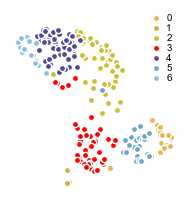

In [ ]:
%%time

# set parameters
RAND_STATE = 33
best_resolution_ns_2d = np.array([0.9])

# compute 
normalized_multisite_ns, umap_df_multisite_ns, profiles_multisite_ns, modularity = apply_wavemap(multi_sites_templates_ns, RAND_STATE, n_neighbors=N_NEIGHBORS, n_components=2, resolution=best_resolution_ns_2d, verbose=True)

# plot 
fig, ax = plt.subplots(1, figsize=(2.2, 2.2))
n_profiles = profiles_multisite_ns[-1] + 1
ax = plot_embedding(ax, umap_df_multisite_ns, profiles_multisite_ns, colors)
ax.axis("off")

#### Plot AP profiles

cluster_id
0    23
1     9
2    51
3    46
4    49
5    29
6    21
Name: count, dtype: int64

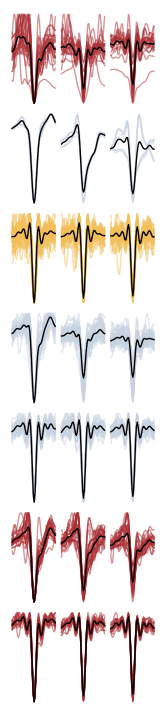

In [13]:
red = np.array([97, 26, 31, 100]) / 255
each_red = np.array([170, 48, 53, 100]) / 255
blue = np.array([41, 48, 115, 100]) / 255
each_blue = np.array([57, 58, 120, 100]) / 255
blue2 = np.array([81, 127, 167, 100]) / 255
each_blue2 = np.array([200, 211, 226, 100]) / 255
purple = np.array([157, 91, 138, 100]) / 255
each_purple = np.array([187, 142, 157, 100]) / 255
gold = [0.9, 0.7, 0.3]
each_gold = [0.95, 0.75, 0.35]

# colors = [red, blue2, red, blue, blue, gold, blue]
# each_colors = [each_red, each_blue2, each_red, each_blue, each_blue2, each_gold, each_blue2]
colors = [red, blue2, gold, blue2, blue2, red, red, gold, gold, gold]
each_colors = [
    each_red,
    each_blue2,
    each_gold,
    each_blue2,
    each_blue2,
    each_red,
    each_red,
    each_gold,
    each_gold,
    each_gold,
]


# setup plot of clusters
fig, axes = plt.subplots(n_profiles, 3, figsize=(1.5, 7))

# nearest site
ax = plot_profiles(
    axes[:, 0],
    normalized_multisite_ns[:, :50],
    umap_df_multisite_ns,
    profiles_multisite_ns,
    each_colors,
    is_title=False,
    is_ylabel=True,
)
for cluster_id in profiles_multisite_ns:
    ax[cluster_id].plot(
        np.nanmean(
            normalized_multisite_ns[
                umap_df_multisite_ns["cluster_id"] == cluster_id, :50
            ],
            axis=0,
        ),
        color="k",
        linewidth=1,
    )
    ax[cluster_id].axis("off")

# 2nd nearest site
ax = plot_profiles(
    axes[:, 1],
    normalized_multisite_ns[:, 50:100],
    umap_df_multisite_ns,
    profiles_multisite_ns,
    each_colors,
    is_title=False,
    is_ylabel=False,
)
for cluster_id in profiles_multisite_ns:
    ax[cluster_id].plot(
        np.nanmean(
            normalized_multisite_ns[
                umap_df_multisite_ns["cluster_id"] == cluster_id, 50:100
            ],
            axis=0,
        ),
        color="k",
        linewidth=1,
    )
    ax[cluster_id].axis("off")

# 3rd nearest site
ax = plot_profiles(
    axes[:, 2],
    normalized_multisite_ns[:, 100:150],
    umap_df_multisite_ns,
    profiles_multisite_ns,
    each_colors,
    is_title=False,
    is_ylabel=False,
)
for cluster_id in profiles_multisite_ns:
    ax[cluster_id].plot(
        np.nanmean(
            normalized_multisite_ns[
                umap_df_multisite_ns["cluster_id"] == cluster_id, 100:150
            ],
            axis=0,
        ),
        color="k",
        linewidth=1,
    )
    ax[cluster_id].axis("off")

fig.tight_layout(pad=0.1)

umap_df_multisite_ns.value_counts("cluster_id", sort=False)

## Figure source dataset

### Load

In [ ]:
df = pd.read_excel("figures/8_source_data/fig3h/fig3h.xlsx")

### Plot

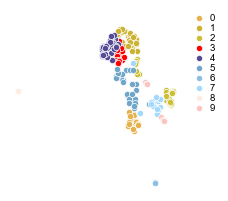

In [ ]:
# setup plots
fig, ax = plt.subplots(figsize=(2.2, 2.2))

# plot clusters
for cluster_id, group in df.groupby("cluster_id"):
    ax.scatter(
        group["x"],
        group["y"],
        color=clusters_color_map[cluster_id],
        label=cluster_id,
        s=20,
        edgecolors="w",
        linewidths=0.5,
    )

# format
ax.axis("off")
ax.legend(
    fontsize=7,
    bbox_to_anchor=(1, 1.1),
    labelspacing=0.1,
    **{"frameon": False, "handletextpad": 0.1},
)

# save
plt.savefig("figures/8_source_data/fig3h/fig3h.svg", **savefig_cfg)